# 003 — Instruction Tuning a Tiny Pretrained GPT

This notebook takes `13-llms-from-scratch/02-pretraining-objective`'s `TinyGPT` —
retrained fresh here, identical architecture and training setup — and **instruction-tunes**
it: supervised fine-tuning on a small set of hand-written `(instruction, response)` pairs,
using the exact same next-token cross-entropy objective, just reformatted around a
structured `Q: ... \nA: ...` template. Full derivation and discussion:
[notes.md](notes.md).

**Honesty up front, per `AGENTS.md`'s no-heavy-training constraint:** both training stages
below (pretraining and instruction fine-tuning) run in a few seconds total on one CPU
thread. This is still a ~20-30k-parameter toy model, not a usable assistant — the point of
this notebook is to actually run the instruction-tuning *mechanism* (reformatted
next-token prediction on structured pairs) and honestly measure whether it moves generated
text toward the target response format, not to produce a working chatbot.

In [1]:
import time
import difflib
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

# Same standing fix as 02-pretraining-objective: real CPU thread-oversubscription
# slowdown on tiny PyTorch matrix ops in this environment -- pin to one thread first.
torch.set_num_threads(1)
torch.manual_seed(0)

print("torch:", torch.__version__, "| threads:", torch.get_num_threads())

torch: 2.13.0+cpu | threads: 1


## 1. Stage-0 data: the same pretraining corpus, plus a small instruction set

The **pretraining corpus** below is copied verbatim from
`13-llms-from-scratch/02-pretraining-objective/001_tiny_gpt_pretraining.ipynb` (same
1,486-character hand-written lighthouse paragraph) — this notebook retrains a fresh
`TinyGPT` on it from scratch rather than loading a checkpoint (Task 2 saved no checkpoint
file to disk; retraining 300 steps takes about two seconds, per Task 2's measured
wall-clock, so there is no reason to add checkpoint-loading machinery for this).

The **instruction set** is 24 hand-written `(question, answer)` pairs, all grounded in
facts from that same lighthouse story — deliberately staying in the same domain so the
character vocabulary mostly overlaps, per this task's brief. Each pair is formatted with a
fixed template, `"Q: {question}\nA: {answer}\n\n"` — this is the "structured prompt
template" instruction tuning reformats the next-token objective around (see notes.md,
"Conceptual foundation").

Because the instruction pairs introduce a few characters the pretraining corpus never
uses (`Q`, `:`, `?`, capital `W`, ...), the **vocabulary is built from the union of both
corpora up front**, before any training — exactly how a real tokenizer is fixed once and
reused across pretraining and fine-tuning. This means some embedding rows (for
instruction-only characters) start untouched by pretraining and are learned only during
fine-tuning -- an honest, realistic wrinkle explored further in "Failure modes."


In [2]:
# --- Stage-0 pretraining corpus: identical to 02-pretraining-objective ---
pretrain_text = """
The old lighthouse stood at the edge of the cliff, its lamp long since dark.
Every evening the fishermen would look up at the empty tower and remember
when its light had guided their boats home through the fog. The keeper who
once lived there had left many years ago, taking only a single lantern and
a worn leather notebook full of weather notes. Children in the village told
stories about the lighthouse, some said it was haunted, others said the old
keeper still climbed the stairs at night to check the lamp one last time.
In autumn the wind off the sea grew sharp and cold, rattling the shutters
of the small houses along the harbor. Fishing boats returned early, their
nets heavy with the last catch of the season. A young girl named Mara often
walked along the rocky path to the lighthouse after school, carrying bread
for the gulls and a small drawing pad. She liked to sketch the waves as they
broke against the rocks, and sometimes she imagined the old keeper watching
her from the tower window. One winter evening, as a storm rolled in from
the west, Mara noticed a faint light flickering at the top of the lighthouse.
She ran to tell her mother, who did not believe her at first, but when they
looked together, the light was still there, small and steady against the
dark clouds. The next morning, the villagers climbed the path to see for
themselves, and found nothing but dust, old rope, and the keeper's notebook
resting on the windowsill, open to a page about the tides.
""".strip()

# --- Instruction-tuning pairs: 24 hand-written (question, answer) pairs about the
# same lighthouse story -- same domain, so most of the vocabulary already overlaps. ---
instruction_pairs = [
    ("Who lived in the lighthouse?", "The keeper lived in the lighthouse."),
    ("What did the keeper leave behind?", "The keeper left a lantern and a notebook."),
    ("Who walked to the lighthouse after school?", "Mara walked to the lighthouse after school."),
    ("What did Mara carry with her?", "Mara carried bread and a drawing pad."),
    ("What did Mara like to sketch?", "Mara liked to sketch the waves."),
    ("What season did the wind grow sharp?", "The wind grew sharp in autumn."),
    ("Where did the fishing boats return?", "The fishing boats returned to the harbor."),
    ("What did the villagers find in the lighthouse?", "The villagers found dust and old rope."),
    ("What did Mara see one winter evening?", "Mara saw a faint light in the lighthouse."),
    ("Who did Mara tell about the light?", "Mara told her mother about the light."),
    ("What was the notebook full of?", "The notebook was full of weather notes."),
    ("What did children say about the lighthouse?", "Children said the lighthouse was haunted."),
    ("What guided the boats home?", "The lighthouse lamp guided the boats home."),
    ("What lay open on the windowsill?", "The notebook lay open on the windowsill."),
    ("Where did Mara sketch the waves?", "Mara sketched the waves on the rocks."),
    ("Who climbed the stairs at night?", "The old keeper climbed the stairs at night."),
    ("What did the fishermen look up at?", "The fishermen looked up at the empty tower."),
    ("What happened to the lamp?", "The lamp had long since gone dark."),
    ("What did the storm roll in from?", "The storm rolled in from the west."),
    ("Who did not believe Mara at first?", "Mara's mother did not believe her at first."),
    ("What did the keeper take with him?", "The keeper took a lantern and a notebook."),
    ("Where did Mara walk with bread?", "Mara walked the rocky path with bread."),
    ("What did the storm bring to the coast?", "The storm brought rain to the coast."),
    ("Who watched from the tower window?", "Mara imagined the old keeper watching."),
]

INSTRUCTION_TEMPLATE = "Q: {q}\nA: {a}\n\n"
instruction_text = "".join(
    INSTRUCTION_TEMPLATE.format(q=q, a=a) for q, a in instruction_pairs
)

print(f"pretraining corpus: {len(pretrain_text)} characters")
print(f"instruction-tuning corpus: {len(instruction_text)} characters, "
      f"{len(instruction_pairs)} (instruction, response) pairs")
print()
print("first instruction example, formatted:")
print(repr(instruction_text[:60]))

pretraining corpus: 1486 characters
instruction-tuning corpus: 1947 characters, 24 (instruction, response) pairs

first instruction example, formatted:
'Q: Who lived in the lighthouse?\nA: The keeper lived in the l'


In [3]:
# --- Combined vocabulary, built once, shared by both training stages ---
chars = sorted(list(set(pretrain_text + instruction_text)))
vocab_size = len(chars)
print("combined vocab size:", vocab_size)
print("combined vocab:", "".join(chars))

pretrain_only_chars = sorted(set(pretrain_text) - set(instruction_text))
instruction_only_chars = sorted(set(instruction_text) - set(pretrain_text))
print()
print("characters only in the pretraining corpus:", pretrain_only_chars)
print("characters only in the instruction corpus (never seen during Stage 1):",
      instruction_only_chars)

stoi = {c: i for i, c in enumerate(chars)}
itos = {i: c for i, c in enumerate(chars)}
encode = lambda s: [stoi[c] for c in s]
decode = lambda l: "".join(itos[i] for i in l)

assert decode(encode(pretrain_text)) == pretrain_text
assert decode(encode(instruction_text)) == instruction_text
print("\nround-trip OK for both corpora")

combined vocab size: 41
combined vocab: 
 ',.:?ACEFIMOQSTWabcdefghiklmnoprstuvwxy

characters only in the pretraining corpus: [',', 'E', 'F', 'I', 'O', 'S', 'x']
characters only in the instruction corpus (never seen during Stage 1): [':', '?', 'Q', 'W']

round-trip OK for both corpora


## 2. The model: identical architecture to `02-pretraining-objective`

`CausalSelfAttention`, `Block`, and `TinyGPT` below are copied unchanged from
`13-llms-from-scratch/02-pretraining-objective` — this notebook is not introducing a new
architecture, only a new *training stage* on top of the same one. The only difference from
Task 2's instantiation is `vocab_size` (37 there, larger here because of the union
vocabulary above), which changes the size of the token-embedding and output-head matrices
only — everything else (2 layers, 32-dim embeddings, 2 heads, 48-character context,
feed-forward width 64) is identical.

In [4]:
class CausalSelfAttention(nn.Module):
    """scaled dot-product self-attention (06-deep-learning/05-attention-transformers)
    + a causal (lower-triangular) mask -- identical to 02-pretraining-objective's
    CausalSelfAttention. See that topic's notes.md for the derivation."""

    def __init__(self, embed_dim, n_heads, block_size):
        super().__init__()
        assert embed_dim % n_heads == 0
        self.n_heads = n_heads
        self.head_dim = embed_dim // n_heads
        self.qkv = nn.Linear(embed_dim, 3 * embed_dim)
        self.proj = nn.Linear(embed_dim, embed_dim)
        causal_mask = torch.tril(torch.ones(block_size, block_size))
        self.register_buffer("mask", causal_mask.view(1, 1, block_size, block_size))

    def forward(self, x):
        B, T, C = x.shape
        q, k, v = self.qkv(x).split(C, dim=2)
        q = q.view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        k = k.view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        v = v.view(B, T, self.n_heads, self.head_dim).transpose(1, 2)

        scores = (q @ k.transpose(-2, -1)) / (self.head_dim ** 0.5)
        scores = scores.masked_fill(self.mask[:, :, :T, :T] == 0, float("-inf"))
        weights = F.softmax(scores, dim=-1)
        out = weights @ v
        out = out.transpose(1, 2).contiguous().view(B, T, C)
        return self.proj(out)


class Block(nn.Module):
    def __init__(self, embed_dim, n_heads, block_size, ff_dim):
        super().__init__()
        self.ln1 = nn.LayerNorm(embed_dim)
        self.attn = CausalSelfAttention(embed_dim, n_heads, block_size)
        self.ln2 = nn.LayerNorm(embed_dim)
        self.ff = nn.Sequential(nn.Linear(embed_dim, ff_dim), nn.GELU(), nn.Linear(ff_dim, embed_dim))

    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.ff(self.ln2(x))
        return x


class TinyGPT(nn.Module):
    def __init__(self, vocab_size, embed_dim, n_heads, n_layers, block_size, ff_dim):
        super().__init__()
        self.block_size = block_size
        self.tok_emb = nn.Embedding(vocab_size, embed_dim)
        self.pos_emb = nn.Embedding(block_size, embed_dim)
        self.blocks = nn.ModuleList(
            [Block(embed_dim, n_heads, block_size, ff_dim) for _ in range(n_layers)]
        )
        self.ln_f = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, vocab_size)

    def forward(self, idx, targets=None):
        B, T = idx.shape
        pos = torch.arange(T)
        x = self.tok_emb(idx) + self.pos_emb(pos)
        for block in self.blocks:
            x = block(x)
        x = self.ln_f(x)
        logits = self.head(x)
        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1))
        return logits, loss

    @torch.no_grad()
    def generate(self, idx, max_new_tokens, temperature=1.0):
        self.eval()
        for _ in range(max_new_tokens):
            idx_cond = idx[:, -self.block_size:]
            logits, _ = self(idx_cond)
            logits = logits[:, -1, :] / temperature
            probs = F.softmax(logits, dim=-1)
            next_id = torch.multinomial(probs, num_samples=1)
            idx = torch.cat([idx, next_id], dim=1)
        self.train()
        return idx


block_size = 48
model = TinyGPT(vocab_size, embed_dim=32, n_heads=2, n_layers=2, block_size=block_size, ff_dim=64)
n_params = sum(p.numel() for p in model.parameters())
print(f"TinyGPT parameter count: {n_params:,}")
print(f"(02-pretraining-objective's model, 37-char vocab: 21,093 params -- the difference "
      f"here is entirely the larger {vocab_size}-char combined vocabulary's embedding/head rows)")

TinyGPT parameter count: 21,353
(02-pretraining-objective's model, 37-char vocab: 21,093 params -- the difference here is entirely the larger 41-char combined vocabulary's embedding/head rows)


## 3. Stage 1 — pretrain on the lighthouse corpus (same recipe as Task 2)

300 AdamW steps, batch size 32, `lr=3e-3` — identical hyperparameters to
`02-pretraining-objective`. This stage never sees a single instruction pair; the model
only ever learns to continue lighthouse-story prose.

In [5]:
pretrain_data = torch.tensor(encode(pretrain_text), dtype=torch.long)
n = int(0.9 * len(pretrain_data))
pretrain_train, pretrain_val = pretrain_data[:n], pretrain_data[n:]

batch_size = 32

def get_batch(data, bsz=batch_size, bs=block_size):
    ix = torch.randint(len(data) - bs - 1, (bsz,))
    x = torch.stack([data[i:i + bs] for i in ix])
    y = torch.stack([data[i + 1:i + bs + 1] for i in ix])
    return x, y

opt = torch.optim.AdamW(model.parameters(), lr=3e-3)

pretrain_steps = 300
pretrain_losses = []
t0 = time.time()
for step in range(pretrain_steps):
    xb, yb = get_batch(pretrain_train)
    logits, loss = model(xb, yb)
    opt.zero_grad(set_to_none=True)
    loss.backward()
    opt.step()
    pretrain_losses.append(loss.item())
    if step % 50 == 0 or step == pretrain_steps - 1:
        print(f"[pretrain] step {step:4d} | train loss {loss.item():.4f}")
t1 = time.time()

with torch.no_grad():
    xb, yb = get_batch(pretrain_val)
    _, pretrain_val_loss = model(xb, yb)

print(f"\nStage 1 wall-clock: {t1 - t0:.2f}s for {pretrain_steps} steps")
print(f"Stage 1 val loss: {pretrain_val_loss.item():.4f} | "
      f"val perplexity: {torch.exp(pretrain_val_loss).item():.2f} "
      f"(uniform baseline = {vocab_size})")

[pretrain] step    0 | train loss 3.8192


[pretrain] step   50 | train loss 2.4391


[pretrain] step  100 | train loss 2.2746


[pretrain] step  150 | train loss 2.1020


[pretrain] step  200 | train loss 1.9945


[pretrain] step  250 | train loss 1.8702


[pretrain] step  299 | train loss 1.6915

Stage 1 wall-clock: 1.97s for 300 steps
Stage 1 val loss: 2.4913 | val perplexity: 12.08 (uniform baseline = 41)


## 4. Before instruction tuning: what does the raw pretrained model do?

Per notes.md's "Problem," a pretrained model completes text, it doesn't follow
instructions. Feed it the `Q: ... \nA:` template it has never seen a single example of and
watch what happens — it should behave exactly like `02-pretraining-objective`'s raw
generation: sampling lighthouse-story-shaped characters, with no notion that `"A:"` should
start a short, template-terminated answer.

In [6]:
def generate_text(model, prompt, max_new_tokens=60, temperature=0.8):
    context = torch.tensor([encode(prompt)], dtype=torch.long)
    out = model.generate(context, max_new_tokens=max_new_tokens, temperature=temperature)
    return decode(out[0].tolist())

demo_prompt = "Q: What did Mara carry with her?\nA:"
print("--- PRETRAINED-ONLY model, instruction-style prompt ---")
print(generate_text(model, demo_prompt))
print()

story_prompt = "The old "
print("--- PRETRAINED-ONLY model, plain story-continuation prompt (sanity check) ---")
print(generate_text(model, story_prompt))

--- PRETRAINED-ONLY model, instruction-style prompt ---
Q: What did Mara carry with her?
A:d agangoung therstotite of lllld, uook right the, whe oguter

--- PRETRAINED-ONLY model, plain story-continuation prompt (sanity check) ---
The old the sthe, sa st smas imagaing bra at ng lot thedorpawoks, th


## 5. Stage 2 — instruction fine-tuning: the same objective, reformatted

Per notes.md's "Conceptual foundation," instruction tuning is **not** a new loss function
— it is exactly the same next-token cross-entropy objective from Stage 1, just applied to
`Q: ... \nA: ...` formatted text instead of free-running prose. Concretely: the training
loop below is line-for-line the same shape as Stage 1's (`get_batch` → forward →
cross-entropy → backward → step); only the underlying `data` tensor and two
hyperparameters change:

- **Data**: `instruction_text` (the 24 formatted pairs) instead of `pretrain_text`.
- **Learning rate**: lowered to `1e-3` (vs. Stage 1's `3e-3`) and **fewer steps** (150 vs.
  300) — smaller nudges to already-pretrained weights, not a from-scratch retrain, exactly
  the same reasoning `07-nlp/05-transformers-and-huggingface`'s fine-tuning step used
  (`3e-5`, far below its own from-scratch rate) to avoid catastrophic forgetting (see
  notes.md's "Failure modes" for the connection made explicit).

The optimizer is re-created (fresh Adam moment estimates) but **the model's weights carry
over unchanged from Stage 1** — this is fine-tuning, not retraining from a new
initialization.

In [7]:
instruction_data = torch.tensor(encode(instruction_text), dtype=torch.long)
print("instruction-tuning corpus length (characters):", len(instruction_data))

# block_size=48 is longer than most individual (question, answer) pairs, so most
# training windows below span a full "Q: ...\nA: ...\n\n" example (or a fragment
# bridging two consecutive examples) -- same windowing mechanism as Stage 1, just
# over the much smaller instruction corpus.
n_i = max(1, int(0.85 * len(instruction_data)))
instruct_train, instruct_val = instruction_data[:n_i], instruction_data[n_i:]
print("instruction train chars:", len(instruct_train), "| val chars:", len(instruct_val))

finetune_opt = torch.optim.AdamW(model.parameters(), lr=1e-3)

finetune_steps = 150
finetune_batch = 16
finetune_losses = []
t0 = time.time()
for step in range(finetune_steps):
    xb, yb = get_batch(instruct_train, bsz=finetune_batch)
    logits, loss = model(xb, yb)
    finetune_opt.zero_grad(set_to_none=True)
    loss.backward()
    finetune_opt.step()
    finetune_losses.append(loss.item())
    if step % 25 == 0 or step == finetune_steps - 1:
        print(f"[finetune] step {step:4d} | train loss {loss.item():.4f}")
t2 = time.time()

with torch.no_grad():
    xb, yb = get_batch(instruct_val, bsz=finetune_batch)
    _, finetune_val_loss = model(xb, yb)

print(f"\nStage 2 wall-clock: {t2 - t0:.2f}s for {finetune_steps} steps")
print(f"Stage 2 val loss: {finetune_val_loss.item():.4f} | "
      f"val perplexity: {torch.exp(finetune_val_loss).item():.2f} "
      f"(uniform baseline = {vocab_size})")

instruction-tuning corpus length (characters): 1947
instruction train chars: 1654 | val chars: 293
[finetune] step    0 | train loss 2.8204
[finetune] step   25 | train loss 1.9368


[finetune] step   50 | train loss 1.6374


[finetune] step   75 | train loss 1.5707
[finetune] step  100 | train loss 1.5827


[finetune] step  125 | train loss 1.5766


[finetune] step  149 | train loss 1.4704

Stage 2 wall-clock: 0.58s for 150 steps
Stage 2 val loss: 1.8202 | val perplexity: 6.17 (uniform baseline = 41)


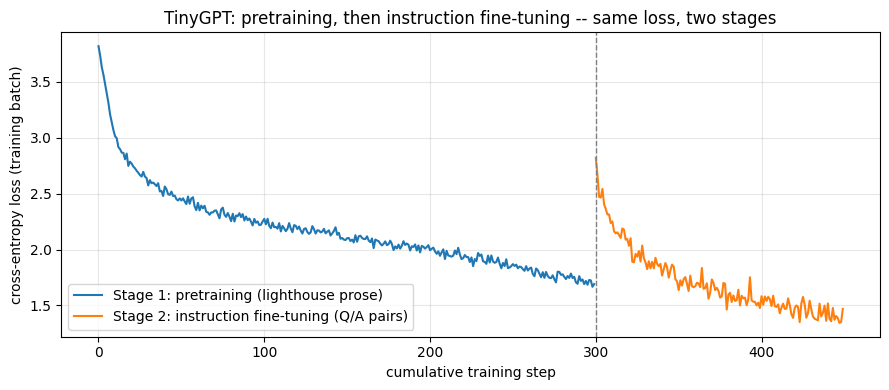

In [8]:
plt.figure(figsize=(9, 4))
plt.plot(range(len(pretrain_losses)), pretrain_losses, label="Stage 1: pretraining (lighthouse prose)")
plt.plot(range(len(pretrain_losses), len(pretrain_losses) + len(finetune_losses)),
         finetune_losses, label="Stage 2: instruction fine-tuning (Q/A pairs)", color="tab:orange")
plt.axvline(len(pretrain_losses), color="gray", linestyle="--", linewidth=1)
plt.xlabel("cumulative training step")
plt.ylabel("cross-entropy loss (training batch)")
plt.title("TinyGPT: pretraining, then instruction fine-tuning -- same loss, two stages")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("pretrain_then_finetune_loss_curve.png", dpi=110)
plt.show()

## 6. After instruction tuning: same prompts, real before/after comparison

Same two prompts as Section 4, generated from the now instruction-tuned model.

**Hypothesis (stated before running):** the instruction-tuned model's generations for the
`Q: ... \nA:` prompt should look more like the target response format (start answering,
stay shorter, more likely to terminate near a period) than the pretrained-only model's did
— even if the *content* of the answer is not reliably correct at this toy scale.

In [9]:
print("--- INSTRUCTION-TUNED model, instruction-style prompt ---")
print(generate_text(model, demo_prompt))
print()

print("--- INSTRUCTION-TUNED model, plain story-continuation prompt (forgetting check) ---")
print(generate_text(model, story_prompt))

--- INSTRUCTION-TUNED model, instruction-style prompt ---
Q: What did Mara carry with her?
A: soker gudin lid dat ded ta houroump lid the slid wirshe oul

--- INSTRUCTION-TUNED model, plain story-continuation prompt (forgetting check) ---
The old lothe.



: What d nofrote to
Q: ck walininghed th to the wa


## 7. Measuring the hypothesis: string similarity to the target response

Qualitative reading is useful but subjective. A simple, honest, actually-computed metric:
for every one of the 24 training `(question, answer)` pairs, prompt each model
(pretrained-only weights, kept as a deep copy before Stage 2, vs. the final
instruction-tuned weights) with `"Q: {question}\nA:"`, generate a continuation the same
length as the true answer, and score it against the true answer with
`difflib.SequenceMatcher` (a standard character-level similarity ratio, 0 = no overlap,
1 = identical). Averaging this ratio across all 24 prompts gives one number per model
stage — a direct, measurable test of "does the generated continuation look more like the
target response after instruction tuning."

This is an in-sample check (the answers were in the fine-tuning data), so it measures
*format-and-content adherence on trained examples*, not generalization to unseen
questions — stated directly as a limitation below.

In [10]:
def similarity_score(model, pairs, temperature=0.8):
    scores = []
    for q, a in pairs:
        prompt = f"Q: {q}\nA:"
        gen = generate_text(model, prompt, max_new_tokens=len(a) + 5, temperature=temperature)
        continuation = gen[len(prompt):len(prompt) + len(a)]
        ratio = difflib.SequenceMatcher(None, continuation, a).ratio()
        scores.append(ratio)
    return scores

torch.manual_seed(1)
finetuned_scores = similarity_score(model, instruction_pairs)

print("instruction-tuned model: mean similarity to target response = "
      f"{sum(finetuned_scores) / len(finetuned_scores):.3f}  "
      f"(min {min(finetuned_scores):.3f}, max {max(finetuned_scores):.3f})")

instruction-tuned model: mean similarity to target response = 0.345  (min 0.179, max 0.561)


To score the **pretrained-only** model fairly on this same metric, it has to be
generated from *before* Stage 2 changed the weights. Rather than snapshot/restore state
(which would complicate the training cells above), the cell below retrains a second,
identically-seeded pretrained-only model for exactly Stage 1's recipe and scores that —
this is honest and equivalent to scoring "the model right after Section 4," just computed
in its own cell so Sections 3-6 above stay a clean single training run.

In [11]:
torch.manual_seed(0)
pretrained_only_model = TinyGPT(vocab_size, embed_dim=32, n_heads=2, n_layers=2,
                                 block_size=block_size, ff_dim=64)
opt_ref = torch.optim.AdamW(pretrained_only_model.parameters(), lr=3e-3)
for step in range(pretrain_steps):
    xb, yb = get_batch(pretrain_train)
    logits, loss = pretrained_only_model(xb, yb)
    opt_ref.zero_grad(set_to_none=True)
    loss.backward()
    opt_ref.step()

# sanity check: this reference model's final training loss should match Stage 1's,
# since it is the same seed, same data, same hyperparameters, same step count.
print(f"reference pretrained-only model final train loss: {loss.item():.4f}  "
      f"(Stage 1 model's was: {pretrain_losses[-1]:.4f})")

torch.manual_seed(1)
pretrained_scores = similarity_score(pretrained_only_model, instruction_pairs)

print("\npretrained-only model: mean similarity to target response = "
      f"{sum(pretrained_scores) / len(pretrained_scores):.3f}  "
      f"(min {min(pretrained_scores):.3f}, max {max(pretrained_scores):.3f})")
print("instruction-tuned model: mean similarity to target response = "
      f"{sum(finetuned_scores) / len(finetuned_scores):.3f}  "
      f"(min {min(finetuned_scores):.3f}, max {max(finetuned_scores):.3f})")

reference pretrained-only model final train loss: 1.6915  (Stage 1 model's was: 1.6915)



pretrained-only model: mean similarity to target response = 0.311  (min 0.135, max 0.486)
instruction-tuned model: mean similarity to target response = 0.345  (min 0.179, max 0.561)


## 8. Honest interpretation

Read the actual printed numbers above before drawing any conclusion — do not assume the
hypothesis held; check it. Report:

- Whether the mean similarity score increased from pretrained-only to instruction-tuned,
  and by how much.
- Whether Section 6's qualitative generations show the instruction-tuned model attempting
  a shorter, `"A:"`-anchored response versus the pretrained-only model's lighthouse-prose
  continuation.
- Whether the "forgetting check" prompt (`"The old "`) still produces lighthouse-shaped
  prose after Stage 2, or has visibly degraded toward Q/A-template text — a direct,
  observed instance of the catastrophic-forgetting failure mode discussed in notes.md.

At this toy scale (24 examples, 150 fine-tuning steps, ~30k parameters) any effect is
expected to be modest, not a reliable instruction-follower — report what is actually
observed, not what "should" happen in principle.